In [2]:
import pandas as pd
import numpy as np
import polars as pl
import plotly.graph_objects as go

from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# data loading
import sys
sys.path.insert(0, '/Users/zzhu/JupyterLab/MarketMaking/_packages')
from tardis_loader import TardisLoader

import nest_asyncio
nest_asyncio.apply()

# plot
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# exchange data info
# https://api.tardis.dev/v1/exchanges/binance

# For generate_combination function
import json
from itertools import product
from typing import List, Dict, Tuple

# For Tardis download error
from urllib.error import HTTPError

# For pandas print setting
pd.set_option('display.width', None)  # Automatically adjust the width of the display
pd.set_option('display.max_colwidth', None)

import pytz

In [4]:
# Load the format config
with open("./config/format_cfg.json", "r") as f:
    format_cfg = json.load(f)

# Load Tardis credential
root_dir = './data'
api_key = 'TD.sSGNjEpohBl9i0FV.zz0-s-b6DZ9c2lt.uoNpgBPGaTITrA9.YlW26JKS0PSfoOG.2pEnnkHAnTpOloD.3wMo'

Tardis_data = TardisLoader(root_dir, api_key)

In [10]:
def generate_combinations(
    data_type: List[str],
    exchange: List[str],
    symbol: List[str],
    format_config: Dict
) -> List[Tuple[str, str, str]]:
    """
    Generate all possible combinations of data_type, exchange, and symbol,
    while formatting exchange and symbol based on the provided format_config.
    """
    combinations = []

    for dt, ex, sym in product(data_type, exchange, symbol):
        # Extract the base exchange name (e.g., 'bybit' from 'bybit-spot')
        base_exchange, market_type = ex.split('-')
        
        # Ensure the base exchange and market type exist in the config
        if base_exchange in format_config and market_type in format_config[base_exchange]:
            # Format the exchange
            formatted_exchange = format_config[base_exchange][market_type]["exchange"]
            
            # Format the symbol
            symbol_format = format_config[base_exchange][market_type]["symbol"]
            formatted_symbol = sym.lower() + symbol_format
            
            # Append the tuple
            combinations.append((dt, formatted_exchange, formatted_symbol))

    return combinations

In [52]:
def liquidity_examine(start_time_str: str, end_time_str: str, exchanges: list[str], symbol: str) -> pl.DataFrame:
    '''
    granularity='50ms'
    '''
    # Download the dataset - Nov 7 vs Today
    start_time = datetime.strptime(start_time_str, "%Y-%m-%d")
    end_time = datetime.strptime(end_time_str, "%Y-%m-%d")

    # Convert the exchanges' and symbols' format according to format_cfg
    combinations = generate_combinations(data_types, exchanges, [symbol], format_cfg)

    venues = []
    
    for comb in combinations:
        try:
            # Tardis_data.download(start_time, end_time, data_type=comb[0], exchange=comb[1], symbol=comb[2])
            data = Tardis_data.read(start_time, end_time, data_type=comb[0], exchange=comb[1], symbol=comb[2])            
            data = data.group_by_dynamic("timestamp", every=f"{1_000_000}i").agg(
                *[pl.first(col) for col in data.columns if col != "timestamp"]
            )
            venues.append(data)

        except HTTPError:
            print(f'{comb[2]} {comb[0]} not avaliable on {comb[1]}.')
        except Exception as e:
            print(e)

    # Join the bbo data from 3 exchanges to initial timestamp
    venues_liquidity = pl.DataFrame()
    
    for venue in venues:
        venue_name = venue[0]['exchange'][0]
        # Span the price and amount col for next filter step
        asia_tz = pytz.timezone('Asia/Shanghai')  # You can change it to your desired Asia timezone
        order_book_25_resample = (
            venue
            .with_columns(
                pl.from_epoch("timestamp", time_unit="us")
                  .dt.convert_time_zone("UTC")
                  .dt.convert_time_zone(asia_tz.zone)
                  .alias("asia_time")
            )
            .filter(
                (pl.col("asia_time").dt.hour() >= 0) &
                (pl.col("asia_time").dt.hour() < 1)
            )
        )
        
        price_cols = [col for col in order_book_25_resample.columns if col.endswith('.price')]
        amount_cols = [col for col in order_book_25_resample.columns if col.endswith('.amount')]

        ob_price_long = order_book_25_resample.unpivot(on=price_cols, index=['timestamp'], variable_name='price_level', value_name='price')
        ob_amount_long = order_book_25_resample.unpivot(on=amount_cols, index=['timestamp'], variable_name='amount_level', value_name='amount')

        ob_price_long = ob_price_long.with_columns([
            pl.col("price_level").str.replace("price", "amount").alias("amount_level")
        ])

        orderbooks_long = ob_price_long.join(ob_amount_long, on=['timestamp', 'amount_level'], how = 'left')
        
        orderbooks_liquidity = orderbooks_long.group_by('timestamp').agg(
            (pl.col('amount').filter((pl.col('price') >= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()) * 0.9995) & 
                                    (pl.col('price') <= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()))
                                   ).sum() * pl.col('price').first()).alias('bid_liquidity_in_5bps'),
            (pl.col('amount').filter((pl.col('price') >= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()) * 0.999) & 
                                    (pl.col('price') <= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()))
                                   ).sum() * pl.col('price').first()).alias('bid_liquidity_in_10bps'),
            (pl.col('amount').filter((pl.col('price') >= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()) * 0.9985) & 
                                    (pl.col('price') <= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()))
                                   ).sum() * pl.col('price').first()).alias('bid_liquidity_in_15bps'),
            (pl.col('amount').filter((pl.col('price') >= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()) * 0.998) & 
                                    (pl.col('price') <= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()))
                                   ).sum() * pl.col('price').first()).alias('bid_liquidity_in_20bps'),
            (pl.col('amount').filter((pl.col('price') >= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()) * 0.9975) & 
                                    (pl.col('price') <= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()))
                                   ).sum() * pl.col('price').first()).alias('bid_liquidity_in_25bps'),
            (pl.col('amount').filter((pl.col('price') >= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()) * 0.995) & 
                                    (pl.col('price') <= (pl.col('price').filter(pl.col('price_level') == "bids[0].price").first()))
                                   ).sum() * pl.col('price').first()).alias('bid_liquidity_in_50bps'),
        ).sort('timestamp')
        
        venue_stat = orderbooks_liquidity.median().with_columns(
                pl.lit(f'{venue_name}').alias('exchange')
            )
        
        if venues_liquidity.height == 0:
            venues_liquidity = venue_stat
        else:
            venues_liquidity = pl.concat([venues_liquidity, venue_stat])
            
        print(f'{venue_name} is done')
    
    
    # Assuming 'filtered_df' is your DataFrame after filtering
    sum_row = venues_liquidity.select([
        pl.sum(col).alias(col) if venues_liquidity[col].dtype.is_numeric() else pl.lit(None).alias(col)
        for col in venues_liquidity.columns
    ])

    # Add a descriptive column for clarity (optional)
    sum_row = sum_row.with_columns(pl.lit("Aggregated").alias("exchange"))

    # Append sum_row as the last row
    venues_liquidity = pl.concat([sum_row, venues_liquidity], how='vertical')
    
    return venues_liquidity

In [ ]:
# SIGN - Apr 28; INIT - Apr 24; BABY - Apr 10; KAITO - Feb 25 ; IP - Feb 13
start_time_str = "2025-05-10"
end_time_str = "2025-05-20"
exchanges = ['coinbase-spot', 'bybit-spot', 'gate-spot',  'okx-spot', 'kucoin-spot', 'huobi-spot'] 
data_types = ['book_snapshot_25']

coin = 'IP'
venue_stats = liquidity_examine(start_time_str, end_time_str, exchanges, coin)

In [49]:
venue_stats

timestamp,bid_liquidity_in_5bps,bid_liquidity_in_10bps,bid_liquidity_in_15bps,bid_liquidity_in_20bps,bid_liquidity_in_25bps,bid_liquidity_in_50bps,bid_liquidity_in_100bps,exchange
f64,f64,f64,f64,f64,f64,f64,f64,str
1.0487e16,5865.677017,17606.869219,30449.571107,47398.828834,59699.451248,110797.495131,155645.738878,"""Aggregated"""
1.7478e15,1885.722904,5911.62311,6286.822324,6286.822324,6286.822324,6286.822324,6286.822324,"""okex"""
1.7478e15,371.3241,1692.59956,4722.9,8582.28105,11487.24338,24623.26142,38523.67684,"""bybit-spot"""
1.7478e15,1351.71756,3887.36092,6862.08667,12476.953995,17208.70228,37747.88664,63680.54022,"""coinbase"""
1.7478e15,1018.00138,2455.38208,4584.9006,8611.006315,11199.27752,23553.69734,28243.28169,"""gate-io"""
1.7478e15,1043.031472,3183.421684,6667.904705,8106.773408,8227.282318,8228.146145,8228.146145,"""kucoin"""
1.7478e15,195.879601,476.481865,1324.956807,3334.991742,5290.123425,10357.681261,10683.271659,"""huobi"""


In [39]:
venue_stats

timestamp,bid_liquidity_in_5bps,bid_liquidity_in_10bps,bid_liquidity_in_15bps,bid_liquidity_in_20bps,bid_liquidity_in_25bps,bid_liquidity_in_50bps,bid_liquidity_in_100bps,exchange
f64,f64,f64,f64,f64,f64,f64,f64,str
1.0487e16,5865.677017,17606.869219,30449.571107,47398.828834,59699.451248,110797.495131,110797.495131,"""Aggregated"""
1.7478e15,1885.722904,5911.62311,6286.822324,6286.822324,6286.822324,6286.822324,6286.822324,"""okex"""
1.7478e15,371.3241,1692.59956,4722.9,8582.28105,11487.24338,24623.26142,24623.26142,"""bybit-spot"""
1.7478e15,1351.71756,3887.36092,6862.08667,12476.953995,17208.70228,37747.88664,37747.88664,"""coinbase"""
1.7478e15,1018.00138,2455.38208,4584.9006,8611.006315,11199.27752,23553.69734,23553.69734,"""gate-io"""
1.7478e15,1043.031472,3183.421684,6667.904705,8106.773408,8227.282318,8228.146145,8228.146145,"""kucoin"""
1.7478e15,195.879601,476.481865,1324.956807,3334.991742,5290.123425,10357.681261,10357.681261,"""huobi"""


In [34]:
venue_stats

timestamp,bid_liquidity_in_5bps,bid_liquidity_in_10bps,bid_liquidity_in_15bps,bid_liquidity_in_20bps,bid_liquidity_in_25bps,bid_liquidity_in_50bps,exchange
f64,f64,f64,f64,f64,f64,f64,str
1.0487e16,5865.677017,17606.869219,30449.571107,47398.828834,59699.451248,110797.495131,"""Aggregated"""
1.7478e15,1885.722904,5911.62311,6286.822324,6286.822324,6286.822324,6286.822324,"""okex"""
1.7478e15,371.3241,1692.59956,4722.9,8582.28105,11487.24338,24623.26142,"""bybit-spot"""
1.7478e15,1351.71756,3887.36092,6862.08667,12476.953995,17208.70228,37747.88664,"""coinbase"""
1.7478e15,1018.00138,2455.38208,4584.9006,8611.006315,11199.27752,23553.69734,"""gate-io"""
1.7478e15,1043.031472,3183.421684,6667.904705,8106.773408,8227.282318,8228.146145,"""kucoin"""
1.7478e15,195.879601,476.481865,1324.956807,3334.991742,5290.123425,10357.681261,"""huobi"""


In [27]:
venue_stats

timestamp,bid_liquidity_in_5bps,bid_liquidity_in_10bps,bid_liquidity_in_15bps,bid_liquidity_in_20bps,bid_liquidity_in_25bps,exchange
f64,f64,f64,f64,f64,f64,str
1.0487e16,5865.677017,17606.869219,30449.571107,47398.828834,59699.451248,"""Aggregated"""
1.7478e15,1885.722904,5911.62311,6286.822324,6286.822324,6286.822324,"""okex"""
1.7478e15,371.3241,1692.59956,4722.9,8582.28105,11487.24338,"""bybit-spot"""
1.7478e15,1351.71756,3887.36092,6862.08667,12476.953995,17208.70228,"""coinbase"""
1.7478e15,1018.00138,2455.38208,4584.9006,8611.006315,11199.27752,"""gate-io"""
1.7478e15,1043.031472,3183.421684,6667.904705,8106.773408,8227.282318,"""kucoin"""
1.7478e15,195.879601,476.481865,1324.956807,3334.991742,5290.123425,"""huobi"""


In [18]:
venue_stats

timestamp,bid_liquidity_in_5bps,bid_liquidity_in_10bps,bid_liquidity_in_15bps,bid_liquidity_in_20bps,bid_liquidity_in_25bps,exchange
f64,f64,f64,f64,f64,f64,str
1.0487e16,2249.217357,11553.655609,22662.140304,38403.945923,50173.106239,"""Aggregated"""
1.7478e15,1094.149901,4834.962962,6286.514582,6286.822324,6286.822324,"""okex"""
1.7478e15,192.64064,999.38708,3426.29689,7597.3311,10067.43739,"""bybit-spot"""
1.7478e15,384.7026,2546.1425,5501.932315,9636.23868,13625.255565,"""coinbase"""
1.7478e15,482.001745,1931.00392,3857.68851,6798.354375,9862.61856,"""gate-io"""
1.7478e15,95.722471,1120.306095,3255.674244,6805.370022,8160.934448,"""kucoin"""
1.7478e15,0.0,121.853052,334.033763,1279.829421,2170.037952,"""huobi"""


In [66]:
venue_stats

timestamp,bid_liquidity_in_5bps,bid_liquidity_in_10bps,bid_liquidity_in_15bps,bid_liquidity_in_20bps,bid_liquidity_in_25bps,bid_liquidity_in_50bps,bid_liquidity_in_100bps,exchange
f64,f64,f64,f64,f64,f64,f64,f64,str
1.0487e16,5865.677017,17606.869219,30449.571107,47398.828834,59699.451248,110797.495131,155645.738878,"""Aggregated"""
1.7478e15,1885.722904,5911.62311,6286.822324,6286.822324,6286.822324,6286.822324,6286.822324,"""okex"""
1.7478e15,371.3241,1692.59956,4722.9,8582.28105,11487.24338,24623.26142,38523.67684,"""bybit-spot"""
1.7478e15,1351.71756,3887.36092,6862.08667,12476.953995,17208.70228,37747.88664,63680.54022,"""coinbase"""
1.7478e15,1018.00138,2455.38208,4584.9006,8611.006315,11199.27752,23553.69734,28243.28169,"""gate-io"""
1.7478e15,1043.031472,3183.421684,6667.904705,8106.773408,8227.282318,8228.146145,8228.146145,"""kucoin"""
1.7478e15,195.879601,476.481865,1324.956807,3334.991742,5290.123425,10357.681261,10683.271659,"""huobi"""


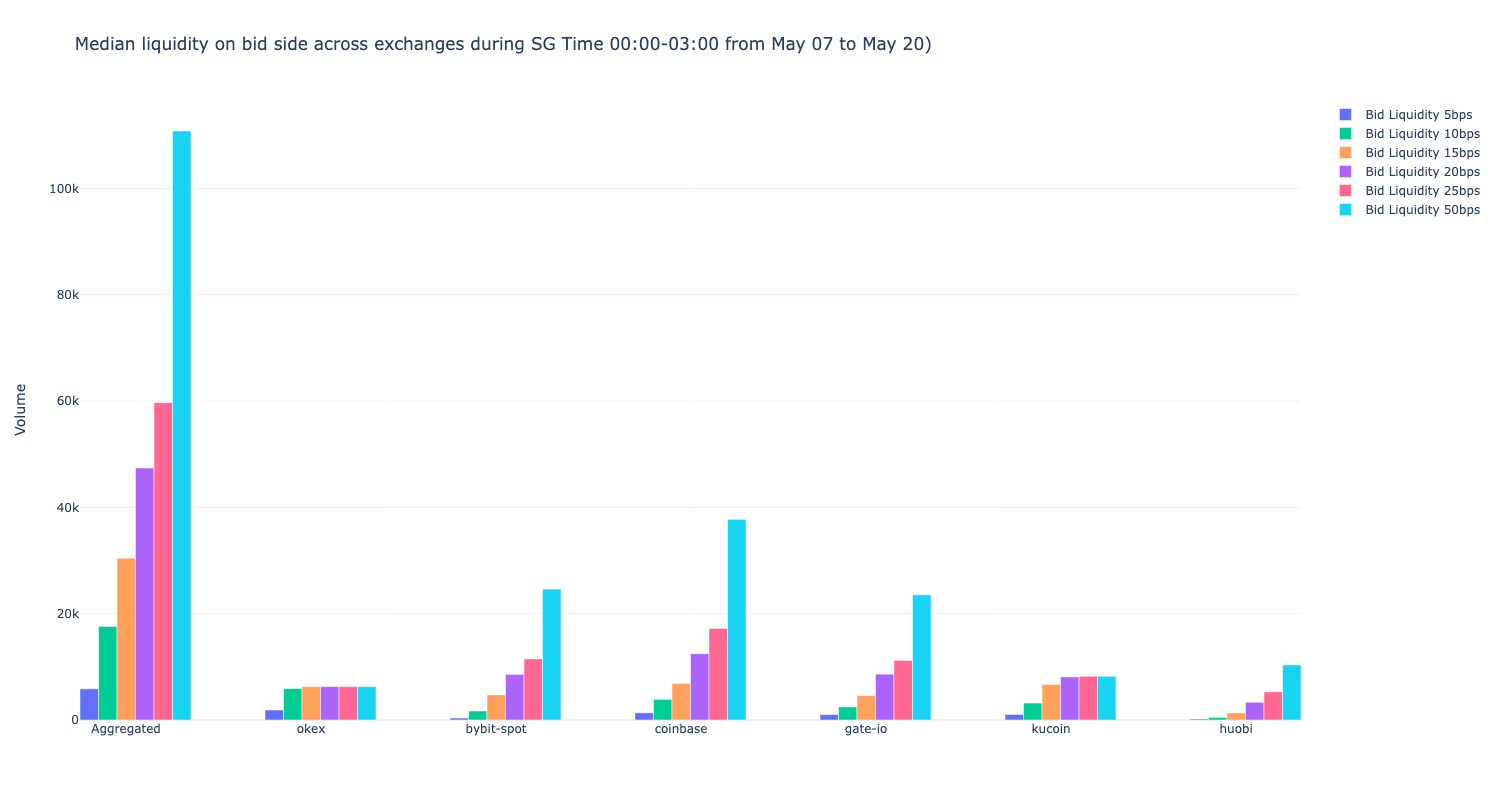

In [68]:
import plotly.graph_objects as go
import pandas as pd

df = pd.DataFrame(venue_stats, columns=venue_stats.columns)

labels = df['exchange']

fig = go.Figure()

bar_width = 0.1
offsets = [-0.2, -0.1, 0, 0.1, 0.2, 0.3]
bps_labels = ['5bps', '10bps', '15bps', '20bps', '25bps', '50bps']
colors_bid = ['#636EFA', '#00CC96', '#FFA15A', '#AB63FA', '#FF6692', '#19D3F3']

for offset, bps_label, color_bid in zip(offsets, bps_labels, colors_bid):
    fig.add_trace(go.Bar(
        x=[x + offset + 0.001 for x in range(len(labels))],
        y=df[f'bid_liquidity_in_{bps_label}'],
        name=f'Bid Liquidity {bps_label}',
        marker_color=color_bid,
        width=bar_width,
    ))

fig.update_layout(
    title=f'Median liquidity on bid side across exchanges during SG Time 00:00-03:00 from May 10 to May 20)',
    xaxis=dict(
        tickmode='array',
        tickvals=list(range(len(labels))),
        ticktext=labels
    ),
    yaxis_title='Volume',
    barmode='group',
    template='plotly_white',
    hovermode='closest',
    width=1500,  # Set the total width of the plot
    height=800,
)

fig.show()